In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scservo_sdk import *                    # Uses SCServo SDK library
from pts_iterator import pts_iterator
import logging

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset
from servo_util import create_zigzag_X, format_para,a2p,r2nd,r2nr,ndmodr,nrselr,nrmodr,nraddr,compose_para
from fit_gaussian import gaussian_2d,gaussian_2d_smooth_heaviside,fit_and_plot,fit_gaussian_2d,fit_gaussian_2d_smooth_heaviside,fit_and_plot_smooth_heaviside
from motor_2d_scan import motor_2d_scan
from servo_const import A_X_XDOT_MASK,A_Y_YDOT_MASK,A_X_Y_MASK,A_XDOT_YDOT_MASK,A_POS_ALL_MASK,B_X_XDOT_MASK,B_Y_YDOT_MASK,B_X_Y_MASK,B_XDOT_YDOT_MASK,B_POS_ALL_MASK,POS_ALL_MASK
from pd import MCP3424_fiber


1.1113125


In [2]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])
servos.torques_enable()
servos.home()
MCP3424_fiber.convert_and_read()

2024-10-02 15:35:22,480 - INFO - Succeeded to open the port
2024-10-02 15:35:22,503 - INFO - Succeeded to change the baudrate
2024-10-02 15:35:22,508 - INFO - Servo 1x: SCServo acc set!
2024-10-02 15:35:22,513 - INFO - Servo 1x: SCServo speed set!
2024-10-02 15:35:22,518 - INFO - Servo 1x: SCServo acc set!
2024-10-02 15:35:22,523 - INFO - Servo 1x: SCServo speed set!
2024-10-02 15:35:22,532 - INFO - Servo 1y: SCServo acc set!
2024-10-02 15:35:22,537 - INFO - Servo 1y: SCServo speed set!
2024-10-02 15:35:22,542 - INFO - Servo 1y: SCServo acc set!
2024-10-02 15:35:22,547 - INFO - Servo 1y: SCServo speed set!
2024-10-02 15:35:22,556 - INFO - Servo 2x: SCServo acc set!
2024-10-02 15:35:22,561 - INFO - Servo 2x: SCServo speed set!
2024-10-02 15:35:22,566 - INFO - Servo 2x: SCServo acc set!
2024-10-02 15:35:22,571 - INFO - Servo 2x: SCServo speed set!
2024-10-02 15:35:22,580 - INFO - Servo 2y: SCServo acc set!
2024-10-02 15:35:22,585 - INFO - Servo 2y: SCServo speed set!
2024-10-02 15:35:22,

1.104

In [11]:
def callback_func(para,
                  pos_mask,
                  zero=None,
                  jac=None,
                  jac_master_mask=None,
                  debug=False,
                  **kwargs):

    para_nr_move = compose_para(para, pos_mask, zero, jac, jac_master_mask,debug=debug,**kwargs)
    #
    if not debug:
        goal_position_list  = r2nd(list(para_nr_move))
        # print(goal_position_list)
        servos.set_position(goal_position_list)
        #
        data_cache = []
        for m in range(2):
            # data = ADS1115_fiber.value
            data = MCP3424_fiber.convert_and_read()
            data_cache.append(data)
        z = float(np.mean(np.array(data)))
        # print(para,z)
        return tuple(para),z
    
cf0 = lambda para: callback_func(para, pos_mask=POS_ALL_MASK)
# cf0([0,0,0,0,0,0,0,0])
cf0([0,0,0,0,0,0,0,0])

((0, 0, 0, 0, 0, 0, 0, 0), 1.0885625)

## 2D Scan

In [4]:
def accept_func_XXDOT_1(xy):
    x,y = xy[0],xy[1]
    slope=1.35
    b=5
    return np.abs(y-x*slope-b)<80
def accept_func_YYDOT_1(xy):
    x,y = xy[0],xy[1]
    slope=-1.36
    b=5
    return np.abs(y-x*slope-b)<80

In [5]:
ZERO_XXDOT_1 = [-6.93742197e+01 ,0,-9.18508692e+01,0,0,0,0,0]
ZERO_YYDOT_1 = [-6.93742197e+01 ,3.48430647e+01,-9.18508692e+01,-4.93558643e+01,0,0,0,0]

2024-10-02 15:35:37,242 - INFO - z0: ((0, 0), 1.1234375)
100%|██████████| 10000/10000 [06:57<00:00, 23.94it/s]
2024-10-02 15:42:34,882 - INFO - going home


1.1612500000000001
0.0


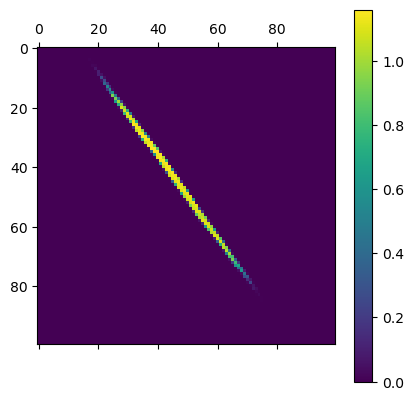

In [6]:
N_pts = 100
SCAN_RANGE = 600
POS_MASK = A_X_XDOT_MASK
# cf = lambda para: callback_func(para, pos_mask=POS_MASK)
cf = lambda para: callback_func(para, zero=ZERO_YYDOT_1, pos_mask=POS_MASK)
# cf = lambda para: callback_func(para, pos_mask=POS_MASK, jac=jac_pm_190, jac_master_mask=A_POS_ALL_MASK)
# X,Y,Z = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
X,Y,Z = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf,accept_func=accept_func_XXDOT_1)

In [14]:
servos.home()

2024-10-02 15:48:47,630 - INFO - going home


In [7]:
np.savez("/home/rydpiservo/servodata/servosetup/scan_clip_XXDOT_1.npz",X=X,Y=Y,Z=Z)

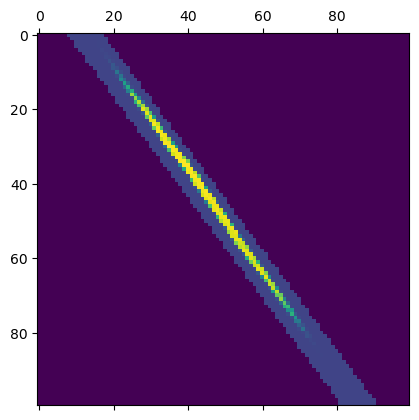

In [12]:
accept_func = accept_func_XXDOT_1
Zacc = np.zeros_like(X)
for i in range(N_pts):
    for j in range(N_pts):
        x,y = X[i,j], Y[i,j]
        Zacc[i,j]=int(accept_func([x,y]))
plt.matshow(Zacc*0.3+Z)

Initial guess for p0:  [-5.05197101e+01 -7.33805466e+01  2.05146408e+04  2.83140327e+04
  3.92419076e+04  1.00000000e-01]


/home/rydpiservo/expctl/src/expctl/servers/servoaligner/fit_gaussian.py:21: RuntimeWarning: overflow encountered in exp
  smooth_transition = 1 / (1 + np.exp((quadratic_form - 1) / transition_width))


[-4.97194590e+01 -7.22245837e+01  7.77268390e+04  1.07328041e+05
  1.48774000e+05  1.43627259e-01]


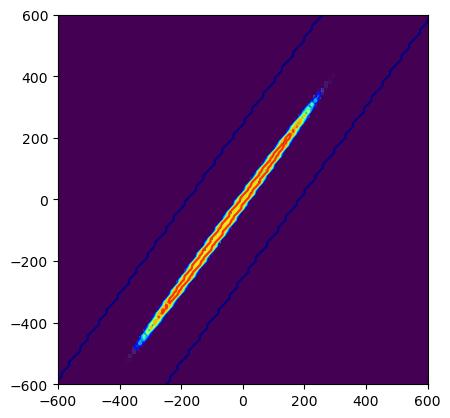

In [13]:
popt=fit_and_plot_smooth_heaviside(X,Y,Z)
print(popt)

In [34]:
cov = np.array([[popt[2],popt[3]],[popt[3],popt[4]]])
eigvals, eigvecs = np.linalg.eig(cov)
np.sqrt(eigvals)

array([ 14.04687281, 474.56078037])

## Iterative Spiral Optimization

In [20]:
zero = np.array([0,0,0,0,0,0,0,0],dtype=float)

In [ ]:
spiral_params = {
    'I_meaningful': 0.01,
    'D': 2,
    'SPIRAL_RESOLUTION': 15,
    'SPIRAL_SPAN': 8,
    'SINGLE_SPIRAL_SPAN': 4,
    'N_LOOPS_BEFORE_RESET_ORIGIN': 0.5,
    'MAX_X0Y0_DISPLACEMENT': 10,
    'COEF_I_RESET_ORIGIN': 1.4,
    'alpha': 0.03,
    'COEF_I_DECAY': 0.995
}
BFGS_params = {"disp": True, "maxiter": 10,  "eps": 5}
logging.getLogger().setLevel(logging.INFO)
#
bounds_single = (-100,100)

def iterative_optimize(pos_mask, method="spiral",zero=None,offset=None,offset_mask=None)->np.ndarray:
    if method == 'L-BFGS-B':
        servos.set_precision(1)
        options = BFGS_params
    elif method == 'spiral':
        servos.set_precision(5)
        options = spiral_params
    #
    N_var = np.sum(pos_mask)
    p0 = np.zeros(N_var)
    bounds = [bounds_single for i in range(N_var)]
    cf = lambda x: callback_func(x,pos_mask,zero=zero,offset=offset,offset_mask=offset_mask)
    #
    para, Ibst = pts_iterator(N_var=N_var,callback_func=cf ,p0=p0, bounds = bounds, options=options, method = method)
    #
    para=list(para)
    Inow = cf(para)[1]
    logging.info(f"Best position: {format_para(para)}, now I: {Inow}")
    #
    if Inow/Ibst > 0.8:
        logging.info(f"New Origin set to be {format_para(para)}")
        zero_fullnd = nraddr(zero,para,pos_mask)
    else:
        logging.info("The intensity is not high enough, operation cancelled.")
        zero_fullnd = np.array(zero)
    #
    logging.info(f"Zero = {zero_fullnd}")
    return zero_fullnd

try:
    logging.info(f"Start optimization with zero = {zero}")
    # zero = iterative_optimize(B_X_Y_MASK, zero=zero,offset=offset,offset_mask=A_POS_ALL_MASK)
    # zero = iterative_optimize(B_X_XDOT_MASK, zero=zero,offset=offset,offset_mask=A_POS_ALL_MASK)
    # zero = iterative_optimize(B_Y_YDOT_MASK, zero=zero,offset=offset,offset_mask=A_POS_ALL_MASK)
    # zero = iterative_optimize(B_POS_ALL_MASK, method='L-BFGS-B',zero=zero,offset=offset,offset_mask=A_POS_ALL_MASK)
    # # #
    # zero = iterative_optimize(A_X_Y_MASK, zero=zero,offset=offset,offset_mask=B_POS_ALL_MASK)
    # zero = iterative_optimize(A_X_XDOT_MASK, zero=zero,offset=offset,offset_mask=B_POS_ALL_MASK)
    # zero = iterative_optimize(A_Y_YDOT_MASK, zero=zero,offset=offset,offset_mask=B_POS_ALL_MASK)
    # zero = iterative_optimize(A_POS_ALL_MASK, method='L-BFGS-B',zero=zero,offset=offset,offset_mask=B_POS_ALL_MASK)

    zero = iterative_optimize(POS_ALL_MASK, method='L-BFGS-B',zero=zero)

except Exception as e:
    # servos.home()
    servos.close()
    print(e)

In [ ]:
para_nr_move = nrmodr(zero,offset,r_mask=A_POS_ALL_MASK)
goal_position_list  = r2nd(para_nr_move,r_mask=POS_ALL_MASK)
print(goal_position_list)
servos.set_position(goal_position_list)
I = MCP3424_fiber.convert_and_read()
print(I)

In [107]:
dataset.append([list(offset),list(zero),I])

In [113]:
np.save(filename,dataset)

In [ ]:
dataset = np.load(filename,allow_pickle=True)
dataset = dataset.item()
print(dataset)

In [93]:
servos.home()